In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [59]:
df = pd.read_csv('/content/credit_card_fraud_2026.csv')

In [60]:
df.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  object 
 3   card_type                     20000 non-null  object 
 4   auth_method                   20000 non-null  object 
 5   channel                       20000 non-null  object 
 6   device_type                   20000 non-null  object 
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  a

In [62]:
df = df.drop(columns=["transaction_id"])

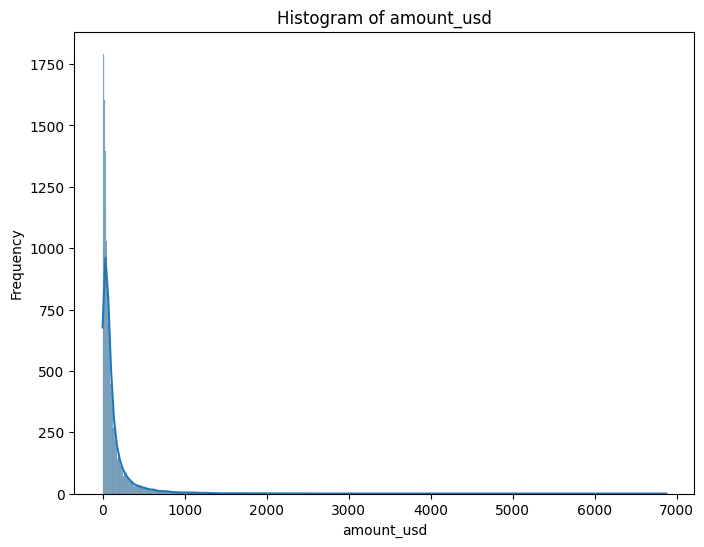

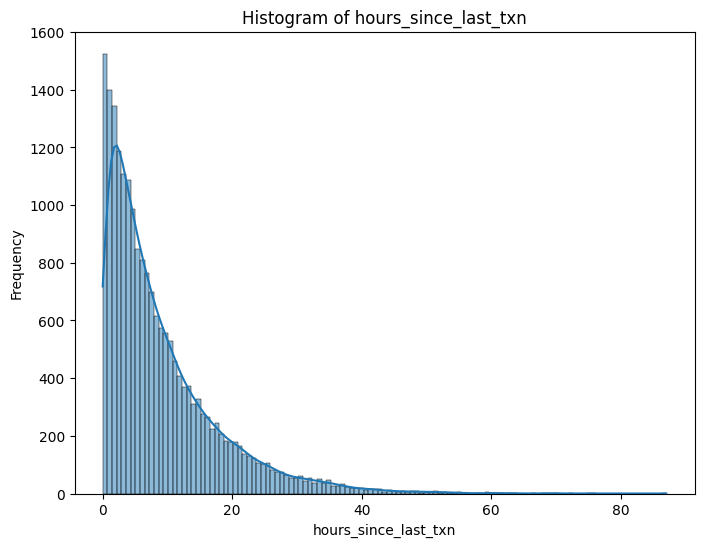

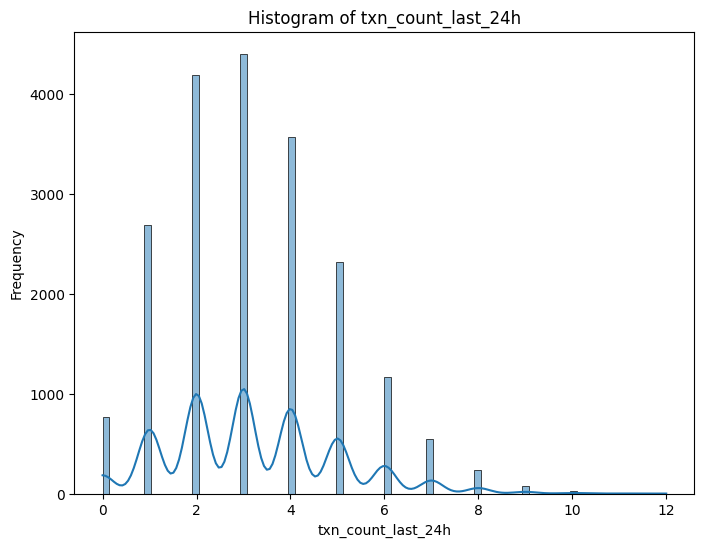

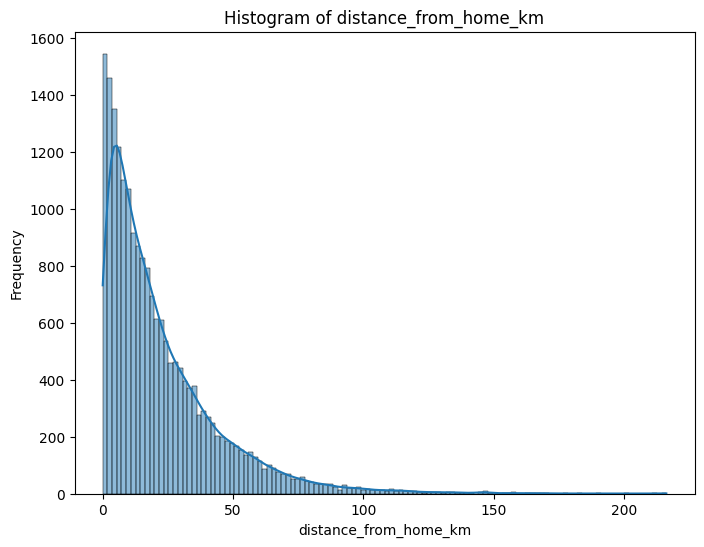

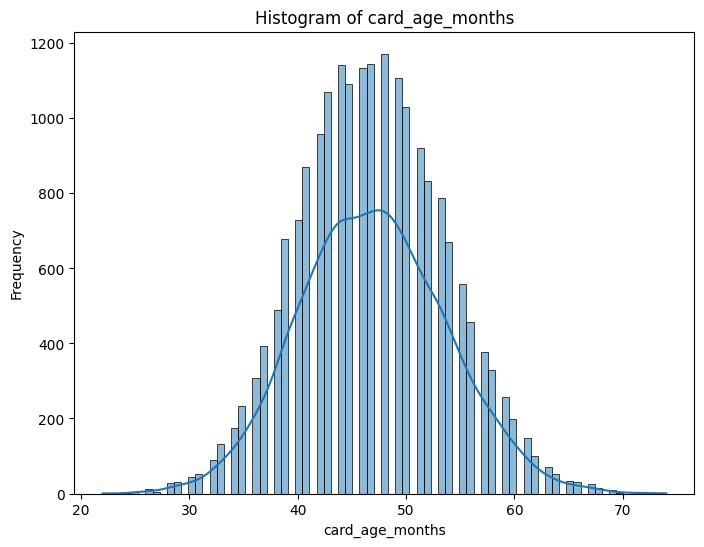

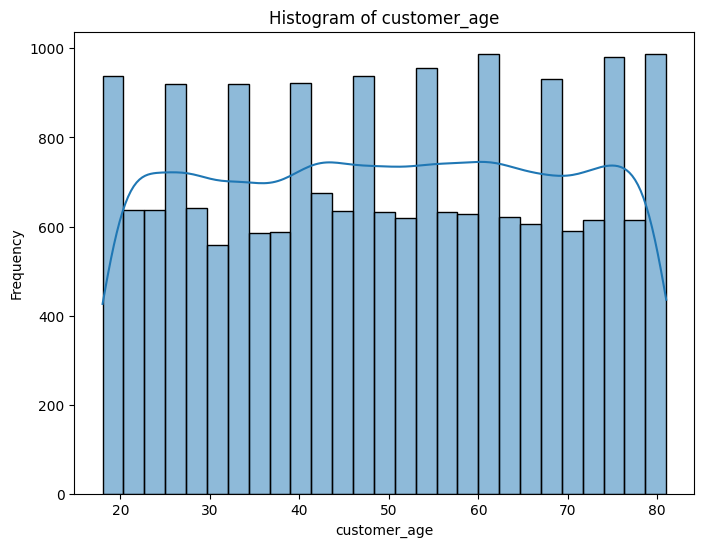

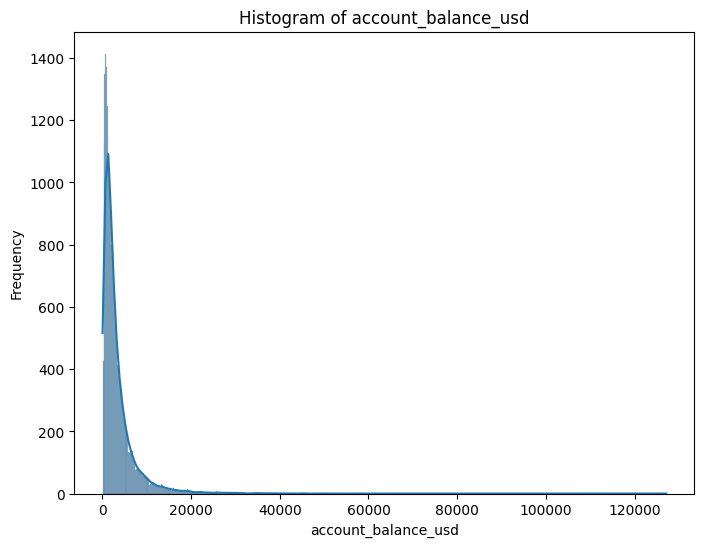

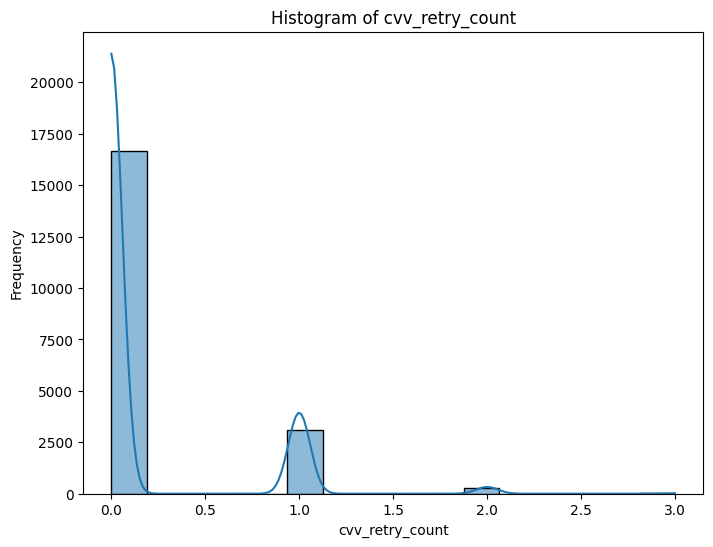

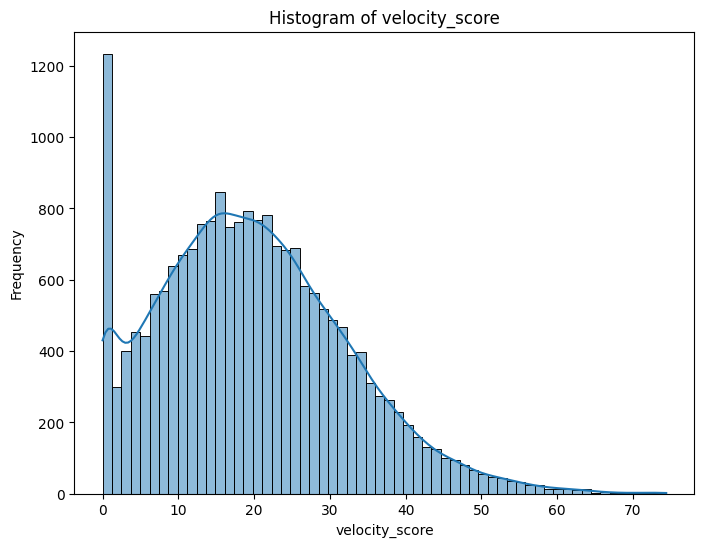

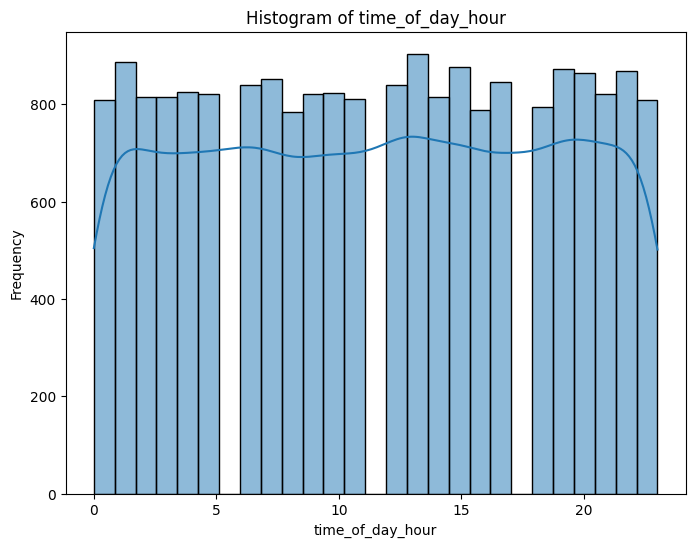

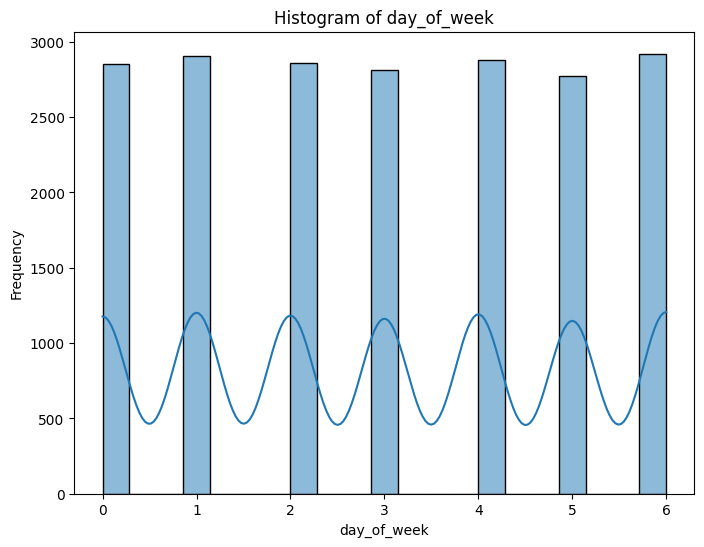

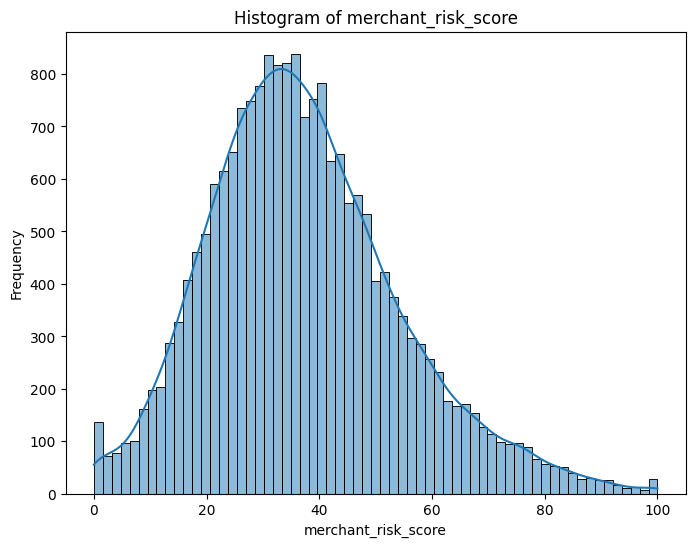

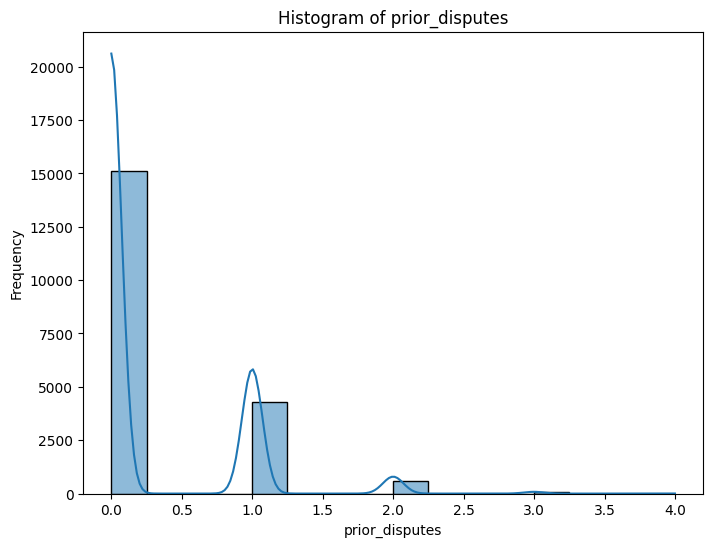

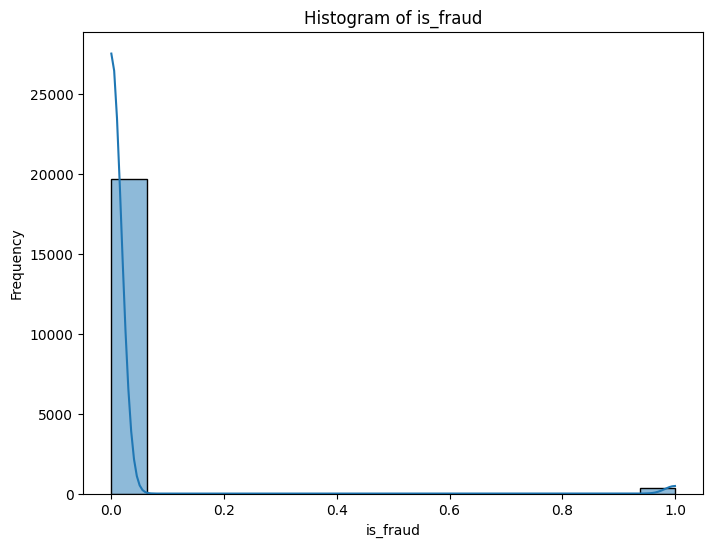

In [63]:
numeric_cols = df.select_dtypes(include=['number']).columns
for col in numeric_cols:
  plt.figure(figsize=(8, 6))
  sns.histplot(df[col], kde=True)
  plt.title(f'Histogram of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.show()

Fraud rate: 1.70%  (339 of 20000)
Accuracy of a "never fraud" model: 98.30%  <-- catches ZERO fraud


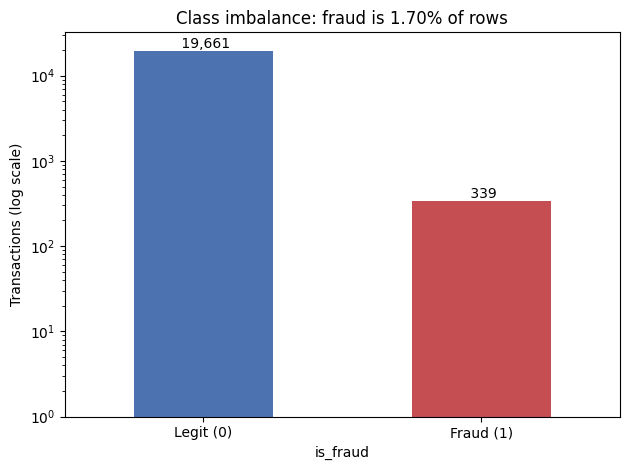

In [64]:
rate = df['is_fraud'].mean()
print(f'Fraud rate: {rate*100:.2f}%  ({df.is_fraud.sum()} of {len(df)})')
print(f'Accuracy of a "never fraud" model: {(1-rate)*100:.2f}%  <-- catches ZERO fraud')

counts = df['is_fraud'].value_counts().sort_index()
ax = counts.plot(kind='bar', color=['#4C72B0', '#C44E52'], log=True)
ax.set_xticklabels(['Legit (0)', 'Fraud (1)'], rotation=0)
ax.set_ylabel('Transactions (log scale)')
ax.set_title(f'Class imbalance: fraud is {rate*100:.2f}% of rows')
for i, v in enumerate(counts):
    ax.text(i, v, f' {v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

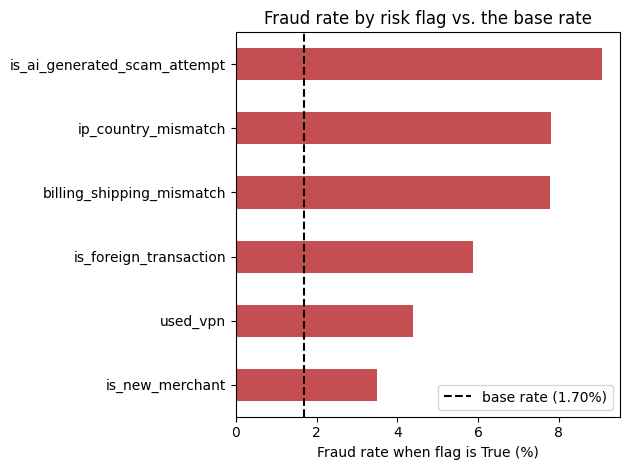

In [65]:
flags = ['ip_country_mismatch', 'billing_shipping_mismatch', 'used_vpn',
         'is_foreign_transaction', 'is_new_merchant', 'is_ai_generated_scam_attempt']
rates = pd.Series({f: df.loc[df[f], 'is_fraud'].mean() * 100 for f in flags}).sort_values()

ax = rates.plot(kind='barh', color='#C44E52')
ax.axvline(rate * 100, color='black', ls='--', label=f'base rate ({rate*100:.2f}%)')
ax.set_xlabel('Fraud rate when flag is True (%)')
ax.set_title('Fraud rate by risk flag vs. the base rate')
ax.legend()
plt.tight_layout()
plt.show()

In [66]:
print('Lift over base rate:')
print((rates / (rate * 100)).round(1).sort_values(ascending=False).to_string())

Lift over base rate:
is_ai_generated_scam_attempt    5.3
billing_shipping_mismatch       4.6
ip_country_mismatch             4.6
is_foreign_transaction          3.5
used_vpn                        2.6
is_new_merchant                 2.1


<Axes: xlabel='is_fraud', ylabel='distance_from_home_km'>

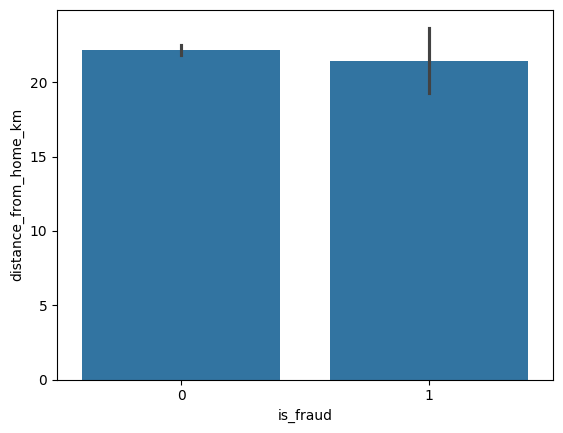

In [67]:
sns.barplot(data=df, x='is_fraud', y = 'distance_from_home_km')

<Axes: xlabel='is_fraud', ylabel='distance_from_home_km'>

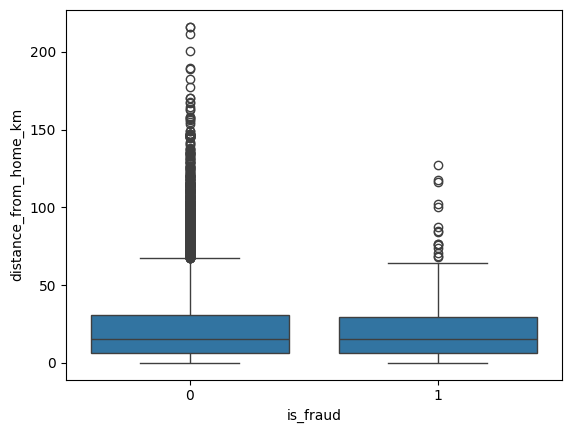

In [68]:
sns.boxplot(data=df, x='is_fraud', y = 'distance_from_home_km')

In [69]:
X = df[df.columns.drop(['is_fraud'])]
y = df['is_fraud']

In [70]:
X.head()

,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,...,used_vpn,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes
0,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,22.35,...,False,False,False,0,0.1,18,3,False,42.3,0
1,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,35.28,...,False,False,False,0,25.8,12,4,False,28.3,0
2,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,9.82,...,True,False,True,0,42.3,5,0,False,24.7,1
3,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,19.72,...,False,False,False,0,28.9,22,6,False,56.2,1
4,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,17.68,...,False,False,False,0,3.9,2,4,False,32.7,0


# One-hot encoding

In [71]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

categorical_cols = ['merchant_category','card_type', 'auth_method', 'channel', 'device_type']
numerical_cols = X.columns.drop(categorical_cols)

X_encoded_array = onehot.fit_transform(X[categorical_cols])

encoded_feature_names = onehot.get_feature_names_out(categorical_cols)
X_encoded_df = pd.DataFrame(X_encoded_array, columns=encoded_feature_names, index=X.index)

X_onehot = pd.concat([X[numerical_cols], X_encoded_df], axis=1)

In [72]:
X_onehot.head()

,amount_usd,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,is_new_merchant,used_vpn,...,channel_Online,channel_POS,device_type_ATM Machine,device_type_Android Phone,device_type_Mac,device_type_POS Terminal,device_type_Smart Watch,device_type_Tablet,device_type_Windows PC,device_type_iPhone
0,42.86,False,13.54,2,22.35,39,25,1080.71,False,False,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4.75,False,0.71,2,35.28,47,33,4463.72,True,False,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,77.18,False,0.35,5,9.82,51,59,366.25,False,True,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1.69,False,3.42,6,19.72,48,28,1345.29,True,False,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,261.68,False,2.43,2,17.68,43,36,4192.59,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [73]:
# Identify boolean columns
boolean_cols = X_onehot.select_dtypes(include=['bool']).columns

# Convert boolean columns to int (0 and 1)
for col in boolean_cols:
    X_onehot[col] = X_onehot[col].astype(int)

print(f"Converted {len(boolean_cols)} boolean columns to int type.")
display(X_onehot[boolean_cols].head())

Converted 6 boolean columns to int type.


,is_foreign_transaction,is_new_merchant,used_vpn,ip_country_mismatch,billing_shipping_mismatch,is_ai_generated_scam_attempt
0,0,0,0,0,0,0
1,0,1,0,0,0,0
2,0,0,1,0,1,0
3,0,1,0,0,0,0
4,0,0,0,0,0,0


In [74]:
X_onehot.head()

,amount_usd,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,is_new_merchant,used_vpn,...,channel_Online,channel_POS,device_type_ATM Machine,device_type_Android Phone,device_type_Mac,device_type_POS Terminal,device_type_Smart Watch,device_type_Tablet,device_type_Windows PC,device_type_iPhone
0,42.86,0,13.54,2,22.35,39,25,1080.71,0,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4.75,0,0.71,2,35.28,47,33,4463.72,1,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,77.18,0,0.35,5,9.82,51,59,366.25,0,1,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1.69,0,3.42,6,19.72,48,28,1345.29,1,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,261.68,0,2.43,2,17.68,43,36,4192.59,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [75]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = [
    'amount_usd',
    'hours_since_last_txn',
    'txn_count_last_24h',
    'distance_from_home_km',
    'card_age_months',
    'customer_age',
    'account_balance_usd',
    'cvv_retry_count',
    'velocity_score',
    'time_of_day_hour',
    'merchant_risk_score',
    'prior_disputes'
]

X_onehot[num_cols] = scaler.fit_transform(X_onehot[num_cols])

In [77]:
X_onehot.head()

,amount_usd,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,is_new_merchant,used_vpn,...,channel_Online,channel_POS,device_type_ATM Machine,device_type_Android Phone,device_type_Mac,device_type_POS Terminal,device_type_Smart Watch,device_type_Tablet,device_type_Windows PC,device_type_iPhone
0,-0.348558,0,0.519224,-0.669654,0.009515,-1.172735,-1.333945,-0.513940,0,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.496871,0,-0.932376,-0.669654,0.594043,0.009227,-0.901362,0.263654,1,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.214995,0,-0.973107,1.016212,-0.556930,0.600208,0.504532,-0.678160,0,1,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-0.508780,0,-0.625764,1.578168,-0.109380,0.156972,-1.171726,-0.453125,1,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.503023,0,-0.737773,-0.669654,-0.201602,-0.581754,-0.739143,0.201334,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_onehot, y, test_size=0.2, random_state=42)

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [80]:
Accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {Accuracy * 100:.2f}%")

Accuracy: 98.50%
